<a href="https://colab.research.google.com/github/sultanhabibllah/pca-formative-team-31/blob/main/PCA_Formative_1%5BPeer_Pair_31%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dataset
The WFP Real-Time Food Prices (RTFP) dataset for Madagascar contains 110,920 monthly observations across 46 columns, covering markets across the country from 2007 to 2026. It includes food-price measures for rice, sugar and wheat flour, an aggregate food price index, inflation measures, reliability or “trust” scores, geographic information, and market identifiers. The raw dataset also contains missing values and several non-numeric variables.

### Use case
Food-price data can support food-security monitoring by showing how prices and inflation vary across markets and over time. In this project, PCA is used to summarize several related food-price indicators into a smaller set of principal components while preserving most of the variation in the data.

### Why PCA is relevant
The analysis uses 12 numeric features related to food prices, inflation, and reliability. Several of these variables are correlated and contain overlapping information, while others operate on different scales. PCA helps reduce this redundancy and produces a lower-dimensional representation that is easier to analyse and visualize.

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

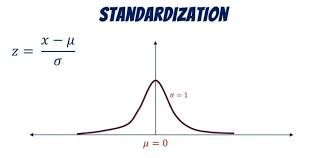


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
standardized_data = None  # Do not use sklearn
standardized_data[:5]  # Display the first few rows of standardized data

In [ ]:
import numpy as np

file_path = "MDG_RTFP_mkt_2007_2026-08-24.csv"

# Select all columns except the 'components' column
use_columns = list(range(46))
use_columns.remove(12)

data = np.genfromtxt(
    file_path,
    delimiter=",",
    names=True,
    dtype=None,
    encoding="utf-8",
    usecols=use_columns
)

In [ ]:
print("Number of rows:", data.shape[0])
print("Number of columns:", len(data.dtype.names))
print(data.dtype.names)

Number of rows: 110920
Number of columns: 45
('ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon', 'geo_id', 'price_date', 'year', 'month', 'currency', 'start_dense_data', 'last_survey_point', 'data_coverage', 'data_coverage_recent', 'index_confidence_score', 'spatially_interpolated', 'rice', 'sugar', 'wheat_flour', 'o_rice', 'h_rice', 'l_rice', 'c_rice', 'inflation_rice', 'trust_rice', 'o_sugar', 'h_sugar', 'l_sugar', 'c_sugar', 'inflation_sugar', 'trust_sugar', 'o_wheat_flour', 'h_wheat_flour', 'l_wheat_flour', 'c_wheat_flour', 'inflation_wheat_flour', 'trust_wheat_flour', 'o_food_price_index', 'h_food_price_index', 'l_food_price_index', 'c_food_price_index', 'inflation_food_price_index', 'trust_food_price_index')


In [ ]:
numeric_columns = []
non_numeric_columns = []

for column in data.dtype.names:
    if np.issubdtype(data[column].dtype, np.number):
        numeric_columns.append(column)
    else:
        non_numeric_columns.append(column)

print("Numeric columns:", numeric_columns)
print("Non-numeric columns:", non_numeric_columns)

Numeric columns: ['lat', 'lon', 'year', 'month', 'sugar', 'wheat_flour', 'o_rice', 'h_rice', 'l_rice', 'c_rice', 'inflation_rice', 'trust_rice', 'o_sugar', 'h_sugar', 'l_sugar', 'c_sugar', 'inflation_sugar', 'trust_sugar', 'o_wheat_flour', 'h_wheat_flour', 'l_wheat_flour', 'c_wheat_flour', 'inflation_wheat_flour', 'trust_wheat_flour', 'o_food_price_index', 'h_food_price_index', 'l_food_price_index', 'c_food_price_index', 'inflation_food_price_index', 'trust_food_price_index']
Non-numeric columns: ['ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'geo_id', 'price_date', 'currency', 'start_dense_data', 'last_survey_point', 'data_coverage', 'data_coverage_recent', 'index_confidence_score', 'spatially_interpolated', 'rice']


In [ ]:
print("Missing values in numeric columns:\n")

for column in numeric_columns:
    missing = np.sum(np.isnan(data[column]))
    if missing > 0:
        print(column, ":", missing)

Missing values in numeric columns:

lat : 236
lon : 236
l_rice : 105637
c_rice : 109305
inflation_rice : 109982
trust_rice : 18800
o_sugar : 18800
h_sugar : 18800
l_sugar : 18800
c_sugar : 24440
inflation_sugar : 18800
trust_sugar : 18800
o_wheat_flour : 18800
h_wheat_flour : 18800
l_wheat_flour : 18800
c_wheat_flour : 24440
inflation_wheat_flour : 18800
trust_wheat_flour : 18800
o_food_price_index : 18800
h_food_price_index : 18800
l_food_price_index : 18800
c_food_price_index : 24440
inflation_food_price_index : 18800
trust_food_price_index : 18800


In [ ]:
selected_features = [
    'c_rice',
    'inflation_rice',
    'trust_rice',
    'c_sugar',
    'inflation_sugar',
    'trust_sugar',
    'c_wheat_flour',
    'inflation_wheat_flour',
    'trust_wheat_flour',
    'c_food_price_index',
    'inflation_food_price_index',
    'trust_food_price_index',
    'data_coverage',
    'index_confidence_score'
]

print("Selected PCA features:")
print(selected_features)
print("\nNumber of features:", len(selected_features))

Selected PCA features:
['c_rice', 'inflation_rice', 'trust_rice', 'c_sugar', 'inflation_sugar', 'trust_sugar', 'c_wheat_flour', 'inflation_wheat_flour', 'trust_wheat_flour', 'c_food_price_index', 'inflation_food_price_index', 'trust_food_price_index', 'data_coverage', 'index_confidence_score']

Number of features: 14


In [ ]:
numeric_pca_features = [col for col in selected_features if col not in non_numeric_columns]
X = np.column_stack([data[column].astype(float) for column in numeric_pca_features])

print("PCA data shape:", X.shape)
print("Missing values before cleaning:", np.sum(np.isnan(X)))

PCA data shape: (110920, 12)
Missing values before cleaning: 424207


In [ ]:
for i in range(X.shape[1]):
    column_median = np.nanmedian(X[:, i])
    X[np.isnan(X[:, i]), i] = column_median

print("Missing values after cleaning:", np.sum(np.isnan(X)))

Missing values after cleaning: 0


In [ ]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_standardized = (X - mean) / std

print("Standardized data shape:", X_standardized.shape)

Standardized data shape: (110920, 12)


In [ ]:
print("Feature means after standardization:")
print(np.round(np.mean(X_standardized, axis=0), 3))

print("\nFeature standard deviations after standardization:")
print(np.round(np.std(X_standardized, axis=0), 3))

Feature means after standardization:
[ 0. -0.  0.  0.  0. -0.  0.  0.  0.  0.  0. -0.]

Feature standard deviations after standardization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = None  # Calculate covariance matrix
cov_matrix

In [ ]:
cov_matrix = np.cov(X_standardized, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (12, 12)


In [ ]:
print("Covariance matrix:")
print(np.round(cov_matrix, 3))

Covariance matrix:
[[ 1.     0.149 -0.018 -0.018  0.113  0.141  0.12   0.075  0.013 -0.006
   0.086  0.023]
 [ 0.149  1.    -0.002  0.006  0.12   0.043  0.001  0.085  0.106  0.114
   0.082  0.03 ]
 [-0.018 -0.002  1.     0.129  0.014 -0.126  0.108  0.217  0.742 -0.095
   0.197  0.958]
 [-0.018  0.006  0.129  1.    -0.056 -0.049  0.223 -0.084  0.136 -0.082
  -0.085  0.125]
 [ 0.113  0.12   0.014 -0.056  1.    -0.048 -0.011  0.762  0.013  0.015
   0.849 -0.   ]
 [ 0.141  0.043 -0.126 -0.049 -0.048  1.     0.181 -0.045 -0.096 -0.114
  -0.03   0.123]
 [ 0.12   0.001  0.108  0.223 -0.011  0.181  1.     0.024  0.116 -0.027
   0.007  0.162]
 [ 0.075  0.085  0.217 -0.084  0.762 -0.045  0.024  1.     0.149 -0.013
   0.951  0.2  ]
 [ 0.013  0.106  0.742  0.136  0.013 -0.096  0.116  0.149  1.     0.163
   0.135  0.802]
 [-0.006  0.114 -0.095 -0.082  0.015 -0.114 -0.027 -0.013  0.163  1.
  -0.014 -0.079]
 [ 0.086  0.082  0.197 -0.085  0.849 -0.03   0.007  0.951  0.135 -0.014
   1.     0.183]
 [ 0.

The covariance matrix is needed because it shows how the standardized features vary together and helps identify relationships between them. PCA uses these relationships to find the directions in which the data varies the most. It also helps reveal redundancy between correlated variables, which is what allows PCA to reduce the number of dimensions while retaining most of the information.

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # Perform eigendecomposition
eigenvalues, eigenvectors

(array([2.00262206e-03, 3.45351936e-02, 2.07542772e-01, 2.48971602e-01,
        6.49281129e-01, 8.16452622e-01, 8.89275170e-01, 1.05772129e+00,
        1.20127658e+00, 1.36649279e+00, 2.40822531e+00, 3.11833110e+00]),
 array([[-8.40856797e-05, -1.28129087e-03, -1.95605182e-02,
          3.78090343e-02,  1.30872637e-01, -7.50612997e-01,
          2.49715206e-01,  1.23713115e-01, -3.45854991e-01,
         -4.59926437e-01, -6.99234956e-02, -6.27597061e-02],
        [ 3.43671962e-04, -1.38300954e-02,  1.65662843e-02,
          7.54519396e-02, -2.57644747e-01,  5.04164336e-01,
          5.07425012e-01, -6.45134290e-02, -6.16117469e-01,
         -1.49713209e-01, -5.45098055e-02, -8.15503295e-02],
        [-6.23791502e-01,  1.21154321e-02,  3.65084893e-01,
          3.34874817e-01, -6.75869575e-02, -6.37332448e-02,
          8.09756241e-02,  1.04034072e-01,  7.63493437e-02,
          1.09376894e-01,  3.86056044e-01, -4.15291942e-01],
        [ 4.11322899e-04, -4.23131491e-03, -2.49537792e-02,

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (12,)
Eigenvectors shape: (12, 12)


In [ ]:
print("Eigenvalues:")
print(np.round(eigenvalues, 4))

Eigenvalues:
[2.0000e-03 3.4500e-02 2.0750e-01 2.4900e-01 6.4930e-01 8.1650e-01
 8.8930e-01 1.0577e+00 1.2013e+00 1.3665e+00 2.4082e+00 3.1183e+00]


In [ ]:
print("First eigenvector:")
print(np.round(eigenvectors[:, 0], 4))

First eigenvector:
[-1.000e-04  3.000e-04 -6.238e-01  4.000e-04  9.000e-04 -1.847e-01
 -2.000e-03 -2.500e-03 -1.522e-01  3.000e-03  3.000e-03  7.440e-01]


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [37]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[-6.27597061e-02, -6.99234956e-02, -4.59926437e-01,
        -3.45854991e-01,  1.23713115e-01,  2.49715206e-01,
        -7.50612997e-01,  1.30872637e-01,  3.78090343e-02,
        -1.95605182e-02, -1.28129087e-03, -8.40856797e-05],
       [-8.15503295e-02, -5.45098055e-02, -1.49713209e-01,
        -6.16117469e-01, -6.45134290e-02,  5.07425012e-01,
         5.04164336e-01, -2.57644747e-01,  7.54519396e-02,
         1.65662843e-02, -1.38300954e-02,  3.43671962e-04],
       [-4.15291942e-01,  3.86056044e-01,  1.09376894e-01,
         7.63493437e-02,  1.04034072e-01,  8.09756241e-02,
        -6.37332448e-02, -6.75869575e-02,  3.34874817e-01,
         3.65084893e-01,  1.21154321e-02, -6.23791502e-01],
       [-4.00116960e-02,  1.92221677e-01, -2.06388109e-01,
         1.76458718e-01, -7.35846963e-01,  2.43500766e-01,
         8.59246983e-02,  5.22690981e-01,  7.56512001e-02,
        -2.49537792e-02, -4.23131491e-03,  4.11322899e-04],
       [-3.41404623e-01, -4.45642921e-01, -1.9885828

In [ ]:
print("Sorted eigenvalues:")
print(np.round(sorted_eigenvalues, 4))

Sorted eigenvalues:
[3.1183e+00 2.4082e+00 1.3665e+00 1.2013e+00 1.0577e+00 8.8930e-01
 8.1650e-01 6.4930e-01 2.4900e-01 2.0750e-01 3.4500e-02 2.0000e-03]


In [ ]:
print("Sorted eigenvectors shape:")
print(sorted_eigenvectors.shape)

Sorted eigenvectors shape:
(12, 12)


In [38]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
explained_variance_percentage = explained_variance * 100

print("Explained variance percentage:")
print(np.round(explained_variance_percentage, 2))

Explained variance percentage:
[2.599e+01 2.007e+01 1.139e+01 1.001e+01 8.810e+00 7.410e+00 6.800e+00
 5.410e+00 2.070e+00 1.730e+00 2.900e-01 2.000e-02]


In [39]:
cumulative_variance = np.cumsum(explained_variance_percentage)

print("Cumulative explained variance:")
print(np.round(cumulative_variance, 2))

Cumulative explained variance:
[ 25.99  46.05  57.44  67.45  76.27  83.68  90.48  95.89  97.97  99.7
  99.98 100.  ]


In [40]:
threshold = 95

num_components = np.argmax(cumulative_variance >= threshold) + 1

print("Variance threshold:", threshold, "%")
print("Number of principal components selected:", num_components)
print(
    "Variance retained:",
    round(cumulative_variance[num_components - 1], 2),
    "%"
)

Variance threshold: 95 %
Number of principal components selected: 8
Variance retained: 95.89 %


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [41]:
# Step 6: Project Data onto Principal Components
reduced_data = np.dot(
    X_standardized,
    sorted_eigenvectors[:, :num_components]
)

reduced_data[:5]

array([[ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361]])

The number of principal components was selected dynamically using a 95% cumulative explained variance threshold. This keeps most of the information in the original dataset while reducing the number of dimensions.

In [ ]:
cumulative_variance = np.cumsum(explained_variance_percentage)

print(np.round(cumulative_variance, 2))

[ 25.99  46.05  57.44  67.45  76.27  83.68  90.48  95.89  97.97  99.7
  99.98 100.  ]


In [ ]:
# Step 6: Project Data onto Principal Components
threshold = 95
num_components = np.argmax(cumulative_variance >= threshold) + 1

reduced_data = np.dot(
    X_standardized,
    sorted_eigenvectors[:, :num_components]
)

reduced_data[:5]

array([[ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361]])

In [ ]:
print("Number of components selected:", num_components)
print(
    "Variance retained:",
    round(cumulative_variance[num_components - 1], 2),
    "%"
)

Number of components selected: 8
Variance retained: 95.89 %


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output Reduced Data
print("Original data shape:", X_standardized.shape)
print("Reduced data shape:", reduced_data.shape)

reduced_data[:5]

Original data shape: (110920, 12)
Reduced data shape: (110920, 8)


array([[ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361],
       [ 0.42574864,  0.19682304, -0.03780336,  0.03614713, -0.02515439,
         0.09858358, -0.02006696, -0.08350361]])

In [ ]:
print("Number of original features:", X_standardized.shape[1])
print("Number of retained components:", reduced_data.shape[1])

Number of original features: 12
Number of retained components: 8


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
# Step 8: Prepare Data for Visualization

before_pca = X_standardized[:, :2]
after_pca = reduced_data[:, :2]

print("Before PCA shape:", before_pca.shape)
print("After PCA shape:", after_pca.shape)

Before PCA shape: (110920, 2)
After PCA shape: (110920, 2)


In [42]:
import matplotlib.pyplot as plt

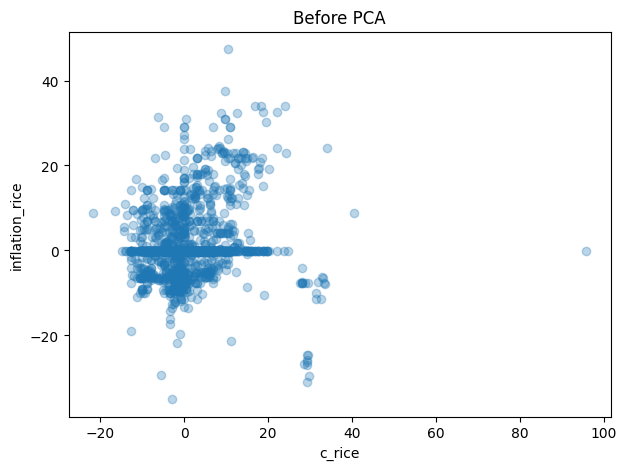

In [43]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_standardized[:, 0],
    X_standardized[:, 1],
    alpha=0.3
)

plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.title("Before PCA")

plt.show()

In [ ]:
print("First 5 observations before PCA:")
print(np.round(before_pca[:5], 3))

First 5 observations before PCA:
[[-0.017 -0.019]
 [-0.017 -0.019]
 [-0.017 -0.019]
 [-0.017 -0.019]
 [-0.017 -0.019]]


In [ ]:
print("First 5 observations after PCA:")
print(np.round(after_pca[:5], 3))

First 5 observations after PCA:
[[0.426 0.197]
 [0.426 0.197]
 [0.426 0.197]
 [0.426 0.197]
 [0.426 0.197]]


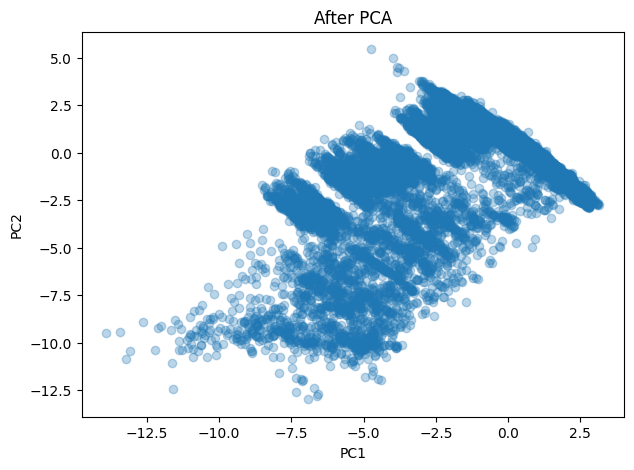

In [44]:
plt.figure(figsize=(7, 5))

plt.scatter(
    reduced_data[:, 0],
    reduced_data[:, 1],
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("After PCA")

plt.show()

In [ ]:
print("Before PCA ranges:")
print("Feature 1:", np.min(before_pca[:, 0]), "to", np.max(before_pca[:, 0]))
print("Feature 2:", np.min(before_pca[:, 1]), "to", np.max(before_pca[:, 1]))

print("\nAfter PCA ranges:")
print("PC1:", np.min(after_pca[:, 0]), "to", np.max(after_pca[:, 0]))
print("PC2:", np.min(after_pca[:, 1]), "to", np.max(after_pca[:, 1]))

Before PCA ranges:
Feature 1: -21.689720195728196 to 95.87082412869599
Feature 2: -34.967950096437235 to 47.393576102735906

After PCA ranges:
PC1: -13.902169071271459 to 3.1599629233381545
PC2: -12.971631000555268 to 5.451659686116248


Before PCA, the selected food-price features are shown in their original feature space, where relationships can be harder to interpret because several variables overlap. After PCA, the data is represented using PC1 and PC2, which capture the strongest directions of variation. The transformed plot preserves the same observations while showing them in a simpler two-dimensional space.

The number of principal components was selected dynamically using a 95% cumulative explained variance threshold. This keeps most of the information in the original dataset while reducing its dimensionality. The trade-off is that a small amount of variance is discarded in exchange for a simpler representation.

Reducing dimensions means some smaller variations in food prices, inflation, trust scores, and market-level patterns are no longer represented. These discarded components may contain local or less dominant differences between markets. However, the retained components preserve the main patterns responsible for most of the variation in the dataset.

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


### Task 3: Performance Optimization and Benchmarking
Measure how efficiently the PCA implementation handles increasing dataset sizes using NumPy-based vectorized operations.

In [45]:
def run_pca(X):
    cov_matrix = np.cov(X, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    reduced = np.dot(X, sorted_eigenvectors)

    return reduced

In [46]:
X_10000 = X_standardized[:10000]

%timeit -n 3 -r 3 run_pca(X_10000)

25.3 ms ± 6.9 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [47]:
X_50000 = X_standardized[:50000]

%timeit -n 3 -r 3 run_pca(X_50000)

The slowest run took 5.59 times longer than the fastest. This could mean that an intermediate result is being cached.
28 ms ± 23.4 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [48]:
%timeit -n 3 -r 3 run_pca(X_standardized)

The slowest run took 4.42 times longer than the fastest. This could mean that an intermediate result is being cached.
60.4 ms ± 30.4 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


The PCA implementation uses NumPy vectorized operations for covariance calculation, eigendecomposition, and matrix multiplication instead of processing observations one by one. Benchmarking 10,000, 50,000, and the full dataset shows how execution time changes as the number of observations increases. This demonstrates the scalability of the implementation on larger datasets.